In [99]:
from qiskit import QuantumCircuit, transpile,QuantumRegister
from qiskit.visualization import plot_bloch_multivector, plot_state_city
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator
import numpy as np
from qiskit.circuit.library import QFT
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, ClassicalRegister
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector, plot_state_city
import numpy as np
import matplotlib.pyplot as plt
from qiskit.visualization import plot_histogram
%matplotlib inline

In [100]:
#Quantum Teleportation Algorithm
'''
Step 1: Creates an unknown qubit state
Step 2:Creates an entangled Bell pair
Step 3:Performs Bell measurement
Step 4:Sends classical bits
Step 5:Applies Pauli corrections
Step 6:Reconstructs the original state on Bob’s qubit
Thus the state is teleported from qubit 0 → qubit 2.
'''

'\nStep 1: Creates an unknown qubit state\nStep 2:Creates an entangled Bell pair\nStep 3:Performs Bell measurement\nStep 4:Sends classical bits\nStep 5:Applies Pauli corrections\nStep 6:Reconstructs the original state on Bob’s qubit\nThus the state is teleported from qubit 0 → qubit 2.\n'

In [101]:
def show_statevector(sv, title=""):
    print("\n" + "="*70)
    print(title)
    print("="*70)
    
    # Print non-zero amplitudes
    for i, amp in enumerate(sv.data):
        if abs(amp) > 1e-6:
            print(f"|{i:010b}>  {amp}")
            
    # Plot Bloch vectors
    fig = plot_bloch_multivector(sv)
    fig.suptitle(title)
    plt.show()


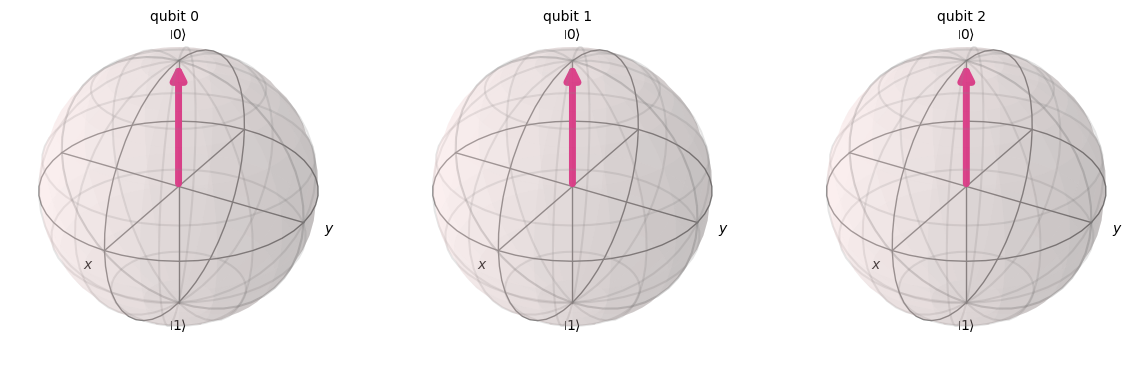

Figure(162.08x367.889)


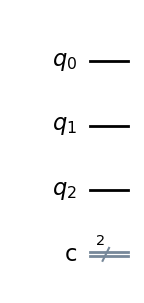


Initial:
|0000000000>  (1+0j)


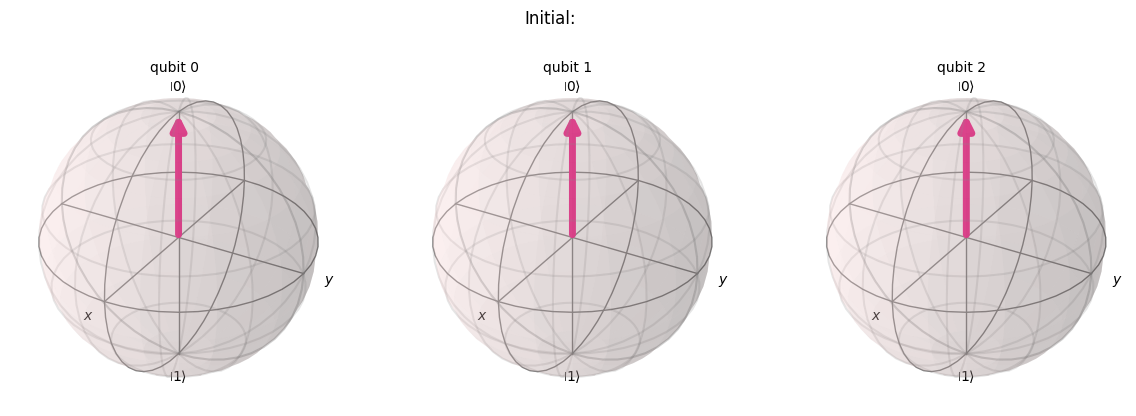

In [102]:
#Create Initial Circuit
qc = QuantumCircuit(3, 2)   # 3 qubits and 2 classical bits

#q0 → state to teleport
#q1 → Alice's entangled qubit
#q2 → Bob's qubit

# Simulate initial state
state_vector= Statevector.from_instruction(qc)
plot_bloch_multivector(state_vector)
plt.show()
print(qc.draw('mpl'))
plt.show()
show_statevector(state_vector, "Initial:")

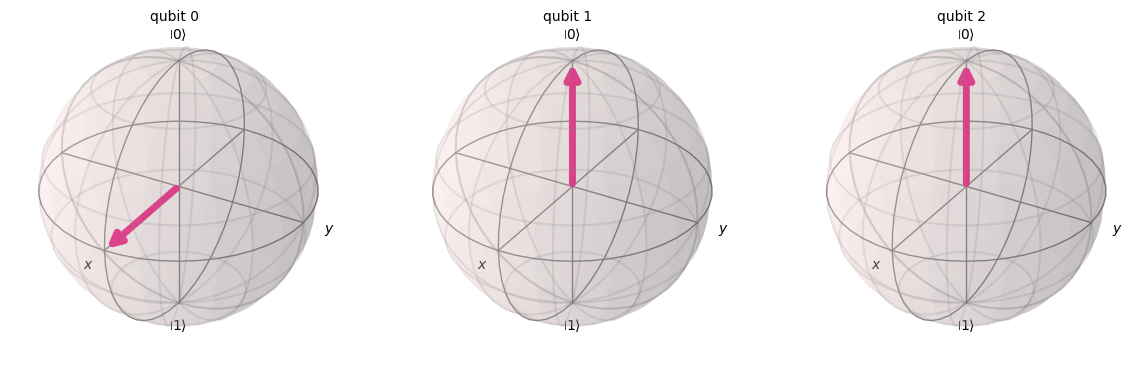

Figure(203.885x367.889)


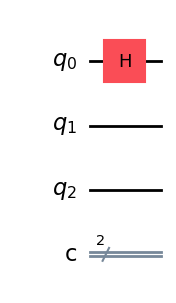


After Superposition:
|0000000000>  (0.7071067811865475+0j)
|0000000001>  (0.7071067811865475+0j)


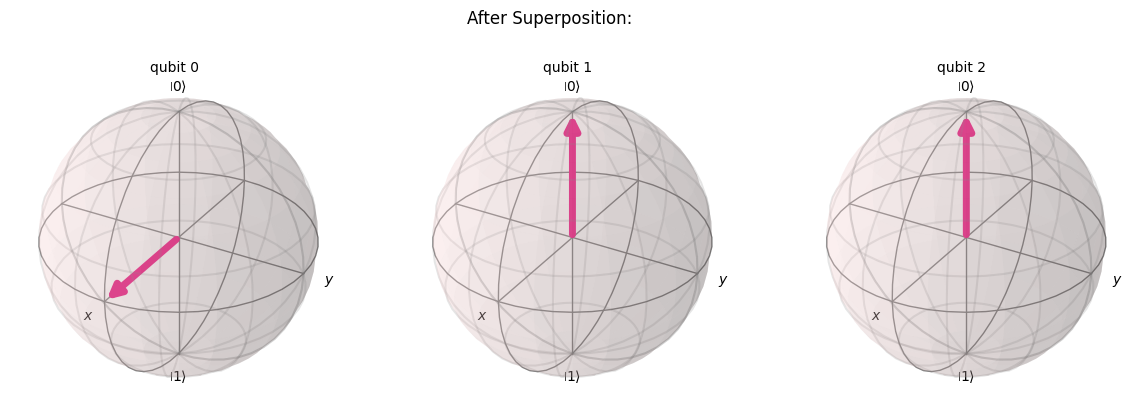

In [103]:
#Step 1
#Prepare the Unknown State (create a superposition state) which Alice has to sent to Bob 
qc.h(0)
# Simulate
state_vector= Statevector.from_instruction(qc)
plot_bloch_multivector(state_vector)
plt.show()
print(qc.draw('mpl'))
plt.show()
show_statevector(state_vector, "After Superposition:")

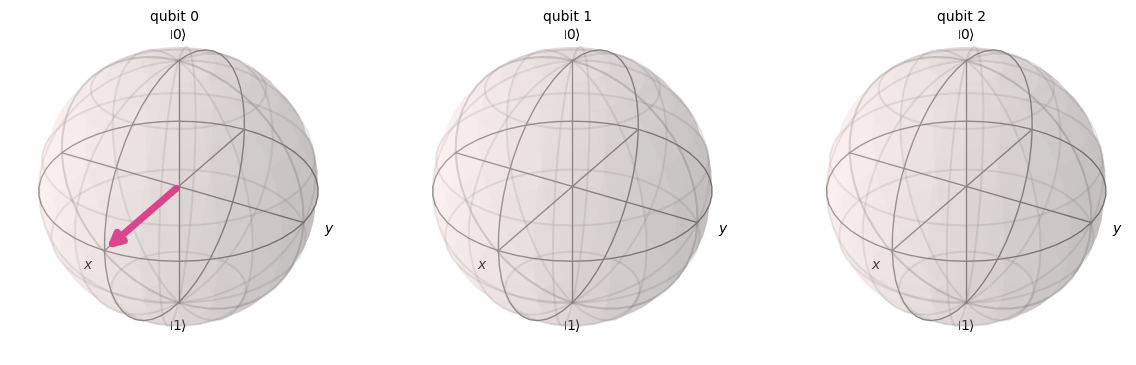

Figure(621.941x367.889)


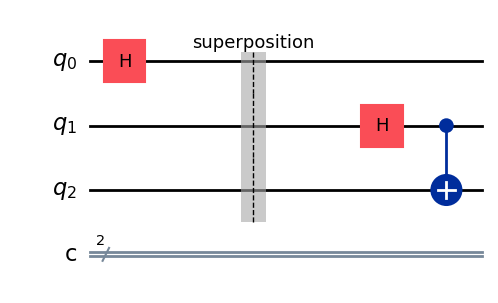


Entanglement:
|0000000000>  (0.4999999999999999+0j)
|0000000001>  (0.4999999999999999+0j)
|0000000110>  (0.4999999999999999+0j)
|0000000111>  (0.4999999999999999+0j)


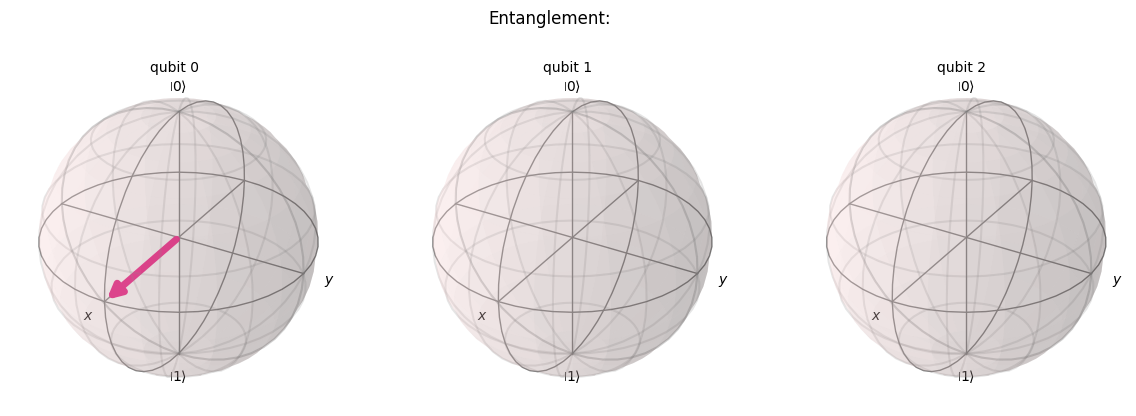

In [104]:
#Step 2: Create Bell Pair (Entanglement) between qubit 1(kept by Alice) and qubit 2(kept by BOb)
qc.barrier(label="superposition")
qc.h(1)
qc.cx(1,2)

# Simulate 
state_vector= Statevector.from_instruction(qc)
plot_bloch_multivector(state_vector)
plt.show()
print(qc.draw('mpl'))
plt.show()
show_statevector(state_vector, "Entanglement:")

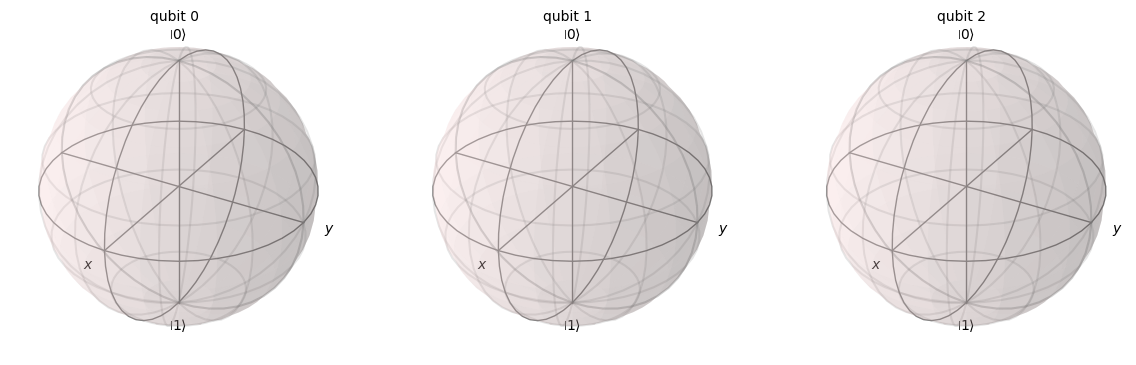

Figure(1040x367.889)


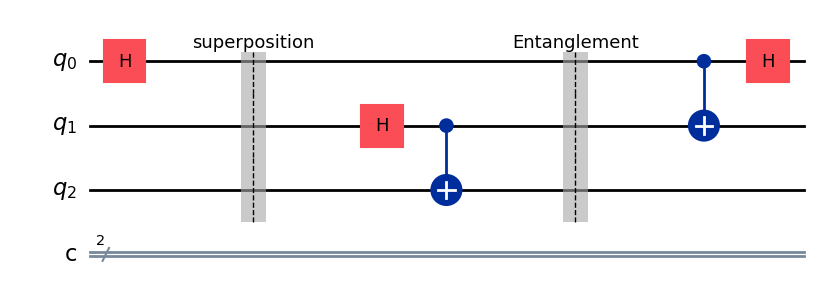


After BSM:
|0000000000>  (0.3535533905932737+0j)
|0000000001>  (0.3535533905932737+0j)
|0000000010>  (0.3535533905932737+0j)
|0000000011>  (-0.3535533905932737+0j)
|0000000100>  (0.3535533905932737+0j)
|0000000101>  (-0.3535533905932737+0j)
|0000000110>  (0.3535533905932737+0j)
|0000000111>  (0.3535533905932737+0j)


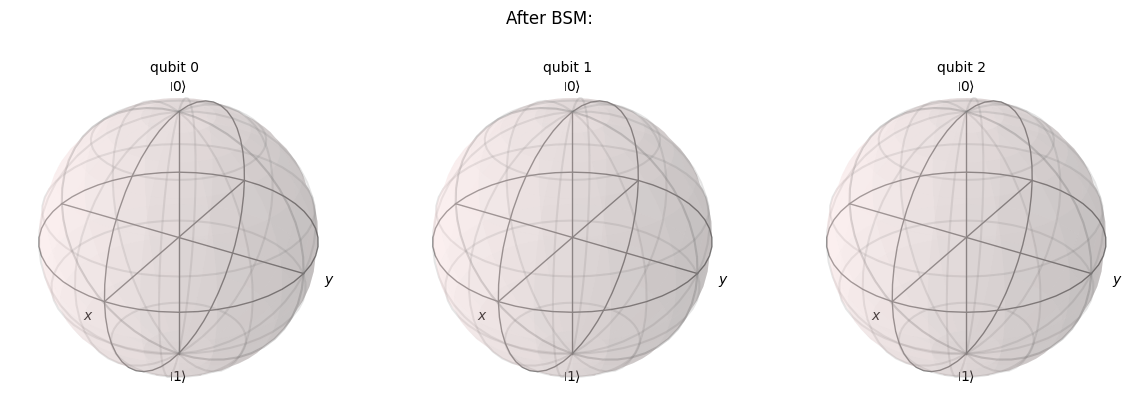

In [105]:
#Bell State Measurement(BSM) by Alice which Destroys the initital state --> Hence No-Cloning is satisfied
qc.barrier(label="Entanglement")
qc.cx(0,1)
qc.h(0)
# Simulate 
state_vector= Statevector.from_instruction(qc)
plot_bloch_multivector(state_vector)
plt.show()
print(qc.draw('mpl'))
plt.show()
show_statevector(state_vector, "After BSM:")

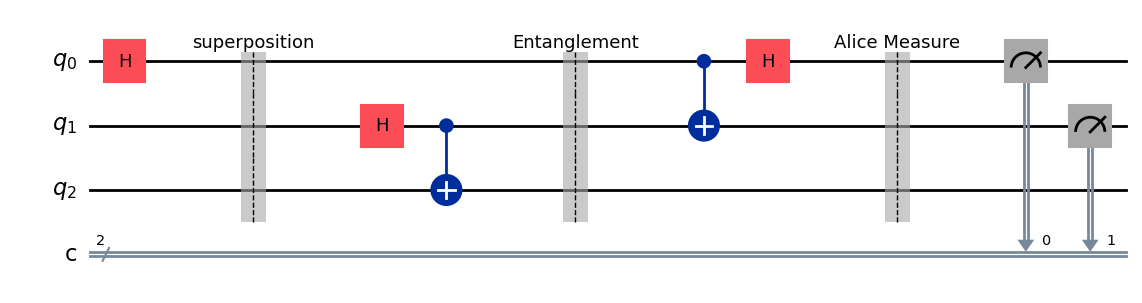

In [106]:
qc.barrier(label="Alice Measure")
qc.measure(0,0)
qc.measure(1,1)
qc.draw('mpl')
#print(qc.draw('mpl'))
plt.show()

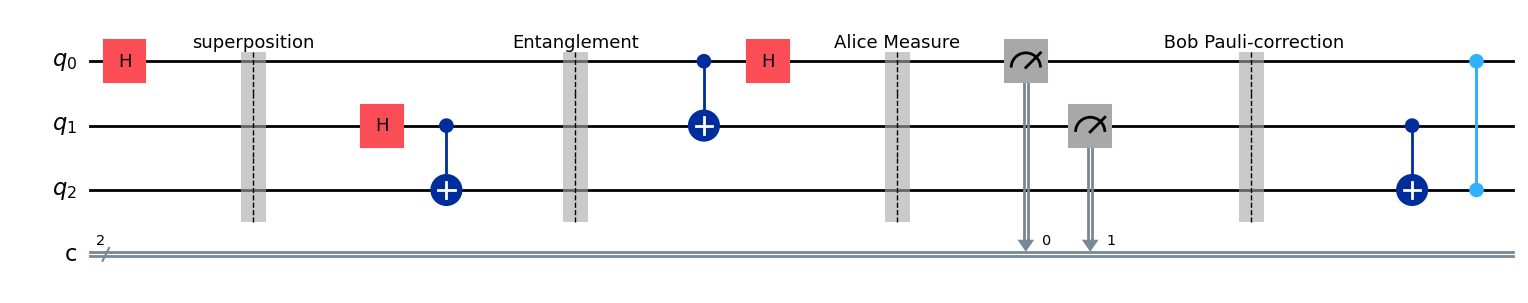

In [107]:
#Classical Conditional Corrections(Bob corrects his qubit depending on Alice’s results)
qc.barrier(label=" Bob Pauli-correction")
qc.cx(1,2)  # Apply CNOT (Bit flip) on qubit_1 and qubit_2
qc.cz(0,2)  # Apply pauli Z (phase flip) on qubit_0 and qubit_2
qc.draw('mpl')
#print(qc.draw('mpl'))
plt.show()     


{'11': 246, '00': 272, '01': 278, '10': 228}


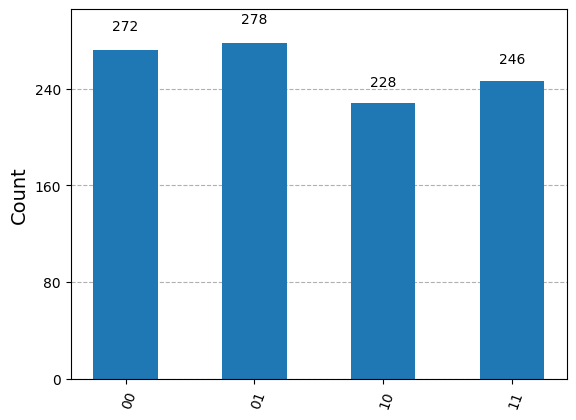

In [108]:
simulator = AerSimulator()

compiled = transpile(qc, simulator)
job = simulator.run(compiled, shots=1024)

result = job.result()
counts = result.get_counts()

print(counts)
plot_histogram(counts)
plt.show()

Figure(1207.22x367.889)


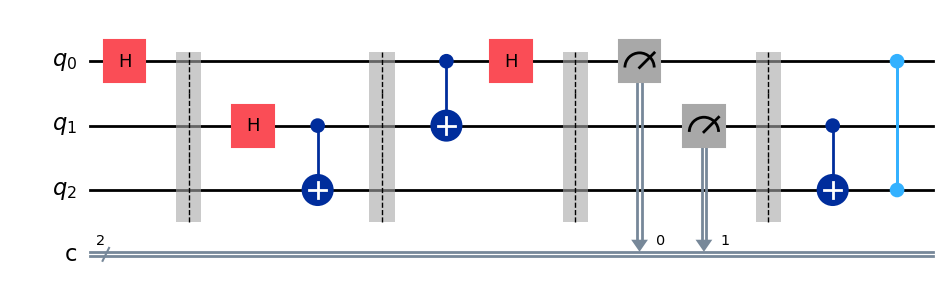

{'10': 258, '01': 259, '00': 248, '11': 259}


In [112]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit import transpile

qc = QuantumCircuit(3,2)

# Prepare state
qc.h(0)
qc.barrier(label="")
# Create Bell pair
qc.h(1)
qc.cx(1,2)
qc.barrier(label="")
# Bell measurement
qc.cx(0,1)
qc.h(0)
qc.barrier(label="")
qc.measure(0,0)
qc.measure(1,1)
qc.barrier(label="")
# Bob correction
qc.cx(1,2)
qc.cz(0,2)

print(qc.draw('mpl'))
plt.show()

simulator = AerSimulator()
compiled = transpile(qc, simulator)

job = simulator.run(compiled, shots=1024)
result = job.result()

print(result.get_counts())

In [110]:
'''Physical meaning
1. Alice’s measurement destroys the original state.(No Cloning Staisfied)
2. Entanglement transfers the information to Bob.
3. Classical bits allow Bob to recover the original state.
'''

'Physical meaning\n1. Alice’s measurement destroys the original state.(No Cloning Staisfied)\n2. Entanglement transfers the information to Bob.\n3. Classical bits allow Bob to recover the original state.\n'

Figure(621.941x284.278)


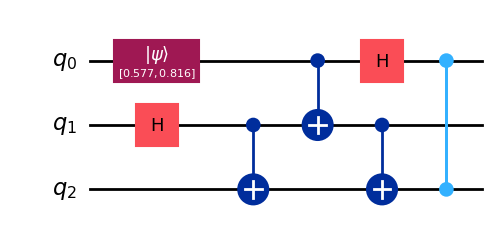

Bob's qubit density matrix:
DensityMatrix([[0.33333333+0.j, 0.47140452+0.j],
               [0.47140452+0.j, 0.66666667+0.j]],
              dims=(2,))


In [111]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, partial_trace
import numpy as np

alpha = 1/np.sqrt(3)
beta = np.sqrt(2/3)

qc = QuantumCircuit(3)

qc.initialize([alpha,beta],0)

qc.h(1)
qc.cx(1,2)

qc.cx(0,1)
qc.h(0)

qc.cx(1,2)
qc.cz(0,2)

print(qc.draw('mpl'))
plt.show()  
state = Statevector.from_instruction(qc)

rho_bob = partial_trace(state,[0,1])

print("Bob's qubit density matrix:")
print(rho_bob)